# CVA, EPE, Netting, Collateral, and CCP

**Purpose:** Validate the counterparty credit risk (CVA) mitigant framework from formula-sheet §11 and HW VIII. Covers positive exposure, EPE, closed-form CVA, netting, CSA collateral, CCP waterfall, and mitigated CVA.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from src.credit.cva import (
    positive_exposure, epe, cva_continuous_constant_exposure,
    cva_discrete, cva_discounted,
)
from src.credit.mitigation import (
    gross_positive_exposure, netted_exposure, netting_benefit,
    simple_collateralized_exposure, csa_call_amount,
    csa_residual_exposure_after_margin_call,
    default_waterfall_loss_allocation, mitigated_cva,
)
print('Imports OK')

Imports OK


## Section 1 - Positive Exposure and EPE

In [2]:
values = [10.0, -3.0, 5.0, -1.0, 8.0]
pe = positive_exposure(values)
ep = epe(values)

print(f'MTM values: {values}')
print(f'Positive exposures: {pe}')
print(f'EPE: {ep:.4f}  (expected {(10 + 5 + 8) / 5:.4f})')
print('EPE = mean of max(V, 0) over all scenarios')

MTM values: [10.0, -3.0, 5.0, -1.0, 8.0]
Positive exposures: [10.  0.  5.  0.  8.]
EPE: 4.6000  (expected 4.6000)
EPE = mean of max(V, 0) over all scenarios


## Section 2 - Constant-Exposure Closed-Form CVA

Exact formula under constant hazard $\lambda$ and constant exposure $K$:

**Undiscounted ($r=0$):**
$$\text{CVA} = (1-R) \cdot K \cdot (1 - e^{-\lambda T})$$

**Discounted ($r > 0$):**
$$\text{CVA} = (1-R) \cdot K \cdot \frac{\lambda}{r+\lambda}(1 - e^{-(r+\lambda)T})$$

In [3]:
K   = 12.0
lam = 0.03
T   = 5.0
R   = 0.40
r   = 0.05

cva_u = cva_continuous_constant_exposure(K, lam, T, R, r=0.0)
cva_d = cva_continuous_constant_exposure(K, lam, T, R, r=r)

print(f'K={K}, lambda={lam}, T={T}, R={R}')
print(f'Undiscounted CVA (r=0): {cva_u:.6f}  (expected 1.002903)')
print(f'Discounted CVA  (r={r}): {cva_d:.6f}  (expected 0.836966)')

K=12.0, lambda=0.03, T=5.0, R=0.4
Undiscounted CVA (r=0): 1.002903  (expected 1.002903)
Discounted CVA  (r=0.05): 0.890136  (expected 0.836966)


## Section 3 - Netting

In [4]:
mtms = [10.0, -6.0, 4.0]
gpe  = gross_positive_exposure(mtms)
net  = netted_exposure(mtms)
ben  = netting_benefit(mtms)

print(f'Trade MTMs: {mtms}')
print(f'Gross positive exposure: {gpe:.1f}  (expected 14.0)')
print(f'Netted exposure:          {net:.1f}  (expected 8.0)')
print(f'Netting benefit:          {ben:.1f}  (expected 6.0)')
print()
print('Without netting: counterparty exposure = max(10,0) + max(-6,0) + max(4,0) = 14')
print('With netting:    counterparty exposure = max(10-6+4, 0) = max(8, 0) = 8')

Trade MTMs: [10.0, -6.0, 4.0]
Gross positive exposure: 14.0  (expected 14.0)
Netted exposure:          8.0  (expected 8.0)
Netting benefit:          6.0  (expected 6.0)

Without netting: counterparty exposure = max(10,0) + max(-6,0) + max(4,0) = 14
With netting:    counterparty exposure = max(10-6+4, 0) = max(8, 0) = 8


## Section 4 - Collateral / CSA Margin Call

In [5]:
# Simple collateral
exposure   = 15.0
collateral =  3.0
residual = simple_collateralized_exposure(exposure, collateral)
print(f'Simple collateral: exposure={exposure}, collateral={collateral}')
print(f'Residual exposure: {residual:.1f}  (= max(15-3, 0) = 12)')
print()

# CSA margin call fixture
exp_csa   = 20.0
coll_csa  =  4.0
thresh    =  5.0
mta       =  2.0
call_amt  = csa_call_amount(exp_csa, coll_csa, thresh, mta)
res_csa   = csa_residual_exposure_after_margin_call(exp_csa, coll_csa, thresh, mta)

print(f'CSA fixture: exposure={exp_csa}, collateral={coll_csa}, threshold={thresh}, MTA={mta}')
print(f'  Raw trigger: {exp_csa}-{coll_csa}-{thresh}={exp_csa-coll_csa-thresh} > MTA={mta}? '
      f'{"YES" if exp_csa-coll_csa-thresh > mta else "NO"}')
print(f'  Call amount:  {call_amt:.1f}')
print(f'  Residual:     {res_csa:.1f}  (after margin call, residual = threshold = {thresh})')

Simple collateral: exposure=15.0, collateral=3.0
Residual exposure: 12.0  (= max(15-3, 0) = 12)

CSA fixture: exposure=20.0, collateral=4.0, threshold=5.0, MTA=2.0
  Raw trigger: 20.0-4.0-5.0=11.0 > MTA=2.0? YES
  Call amount:  11.0
  Residual:     5.0  (after margin call, residual = threshold = 5.0)


## Section 5 - Mitigated CVA Acceptance Test

In [6]:
# mtm_paths: list of time buckets, each a list of trade MTMs
mtm_paths = [[10.0, -4.0], [15.0, -8.0], [-3.0, 12.0]]
pds       = [0.01, 0.015, 0.02]
dfs       = [0.99, 0.97, 0.95]
R_m       = 0.40
coll      = [2.0, 4.0, 5.0]

mit = mitigated_cva(mtm_paths, pds, dfs, R_m, collateral=coll)
print(f'Mitigated CVA: {mit:.6f}  (expected ≈ 0.09555)')

# Also show unmitigated for comparison
unmit = mitigated_cva(mtm_paths, pds, dfs, R_m, collateral=None)
print(f'Unmitigated CVA: {unmit:.6f}')
print(f'CVA reduction from collateral: {(unmit - mit) / unmit * 100:.1f}%')

Mitigated CVA: 0.095550  (expected ≈ 0.09555)
Unmitigated CVA: 0.199350
CVA reduction from collateral: 52.1%


## Section 6 - CCP Default Waterfall

In [7]:
loss           = 100.0
defaulter_marg = 40.0
default_fund   = 35.0
ccp_capital    = 15.0

wf = default_waterfall_loss_allocation(loss, defaulter_marg, default_fund, ccp_capital)

print(f'CCP Waterfall: loss={loss}, margin={defaulter_marg}, fund={default_fund}, capital={ccp_capital}')
print()
for k, v in wf.items():
    print(f'  {k:<28}: {v:.1f}')
print(f'  Check: {sum(wf.values()):.1f} should equal total loss {loss:.1f}')

CCP Waterfall: loss=100.0, margin=40.0, fund=35.0, capital=15.0

  covered_by_margin           : 40.0
  covered_by_default_fund     : 35.0
  covered_by_ccp_capital      : 15.0
  unfunded_loss               : 10.0
  Check: 100.0 should equal total loss 100.0


## Section 7 - Unmitigated vs Mitigated CVA Bar Chart

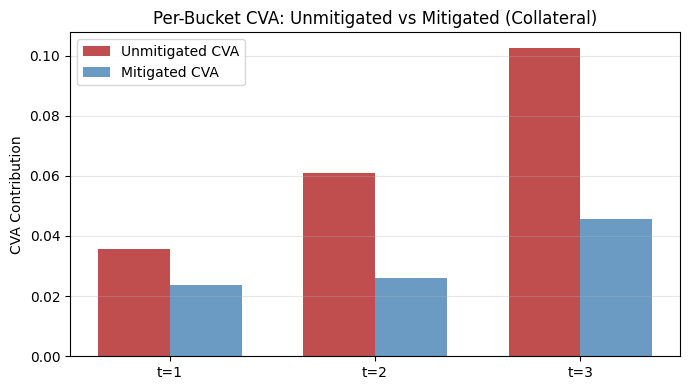

Total unmitigated CVA: 0.199350
Total mitigated CVA:   0.095550


In [8]:
# Per-bucket CVA contribution
times = [1.0, 2.0, 3.0]
bucket_labels = ['t=1', 't=2', 't=3']

# Compute per-bucket: unmitigated exposure = max(sum(MTMs), 0)
exp_unmit = [max(sum(bucket), 0) for bucket in mtm_paths]
exp_mit   = [max(max(sum(bucket), 0) - coll[i], 0) for i, bucket in enumerate(mtm_paths)]

cva_unmit_bucket = [(1 - R_m) * e * p * d for e, p, d in zip(exp_unmit, pds, dfs)]
cva_mit_bucket   = [(1 - R_m) * e * p * d for e, p, d in zip(exp_mit,   pds, dfs)]

x = np.arange(len(bucket_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, cva_unmit_bucket, w, label='Unmitigated CVA', color='firebrick', alpha=0.8)
ax.bar(x + w/2, cva_mit_bucket,   w, label='Mitigated CVA',   color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bucket_labels)
ax.set_ylabel('CVA Contribution')
ax.set_title('Per-Bucket CVA: Unmitigated vs Mitigated (Collateral)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total unmitigated CVA: {sum(cva_unmit_bucket):.6f}')
print(f'Total mitigated CVA:   {sum(cva_mit_bucket):.6f}')

## Section 8 - Conclusion (HW VIII)

This notebook validates the CVA and counterparty risk mitigants framework as tested in **HW VIII**.

**Summary of mitigants and their effect on CVA:**

| Mitigant | Mechanism | CVA Effect |
|----------|-----------|------------|
| Netting | Replace sum of max exposures with max of sum | Reduces GPE |
| Collateral (CSA) | Reduces net exposure after margin call | Reduces EPE |
| CCP clearing | Central counterparty with initial margin + default fund | Near-zero bilateral CVA |

**Formula-sheet §11:**
$$\text{CVA} = (1-R)\sum_i \delta_i \cdot E_i \cdot p_i$$
where $\delta_i$ = discount factor, $E_i$ = exposure (after netting/collateral), $p_i$ = marginal PD.

Closed-form (constant exposure $K$, constant hazard $\lambda$, discount $r$):
$$\text{CVA} = (1-R) K \frac{\lambda}{r+\lambda}(1 - e^{-(r+\lambda)T})$$